<a href="https://colab.research.google.com/github/kiato1970-blip/AI_EKPA/blob/main/ErgasiaM10Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] Φόρτωση δεδομένων από το εικονικό περιβάλλον...


/tmp/ipykernel_22023/1158775807.py:27: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(local_dataset_path)


          Src_IP  Src_Port          Dst_IP  Dst_Port  Protocol  Flow_Duration  \
0  10.152.152.11     57158   216.58.220.99       443         6            229   
1  10.152.152.11     57159   216.58.220.99       443         6            407   
2  10.152.152.11     57160   216.58.220.99       443         6            431   
3  10.152.152.11     49134  74.125.136.120       443         6            359   
4  10.152.152.11     34697  173.194.65.127     19305         6       10778451   

   Total_Fwd_Packet  Total_Bwd_packets  Total_Length_of_Fwd_Packet  \
0                 1                  1                           0   
1                 1                  1                           0   
2                 1                  1                           0   
3                 1                  1                           0   
4               591                400                       64530   

   Total_Length_of_Bwd_Packet  ...  Active_Mean  Active_Std  Active_Max  \
0                

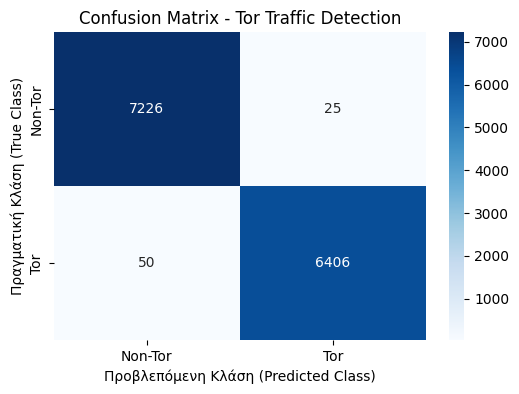

[INFO] Εκπαίδευση του XGBoost Classifier...

=== ΑΠΟΤΕΛΕΣΜΑΤΑ XGBOOST ===
Accuracy Score: 0.9964

Classification Report:
              precision    recall  f1-score   support

     Non-Tor       0.99      1.00      1.00      7251
         Tor       1.00      0.99      1.00      6456

    accuracy                           1.00     13707
   macro avg       1.00      1.00      1.00     13707
weighted avg       1.00      1.00      1.00     13707


[INFO] Δημιουργία Συγκριτικού Πίνακα...

            ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ ΜΟΝΤΕΛΩΝ ΜΜ                 
Μοντέλο Μηχανικής Μάθησης Συνολική Ακρίβεια (Accuracy) Πιστότητα Tor (Precision) Ανάκληση Tor (Recall)
            Random Forest                       99.45%                    99.61%                99.23%
                  XGBoost                       99.64%                    99.86%                99.38%


In [1]:
# ==============================================================================
# ΕΥΦΥΕΣ ΣΥΣΤΗΜΑ ΕΝΤΟΠΙΣΜΟΥ ΚΙΝΗΣΗΣ TOR ΣΤΟ ΕΤΑΙΡΙΚΟ ΔΙΚΤΥΟ
# Μάθημα: Τεχνητή Νοημοσύνη - ΕΚΠΑ
# ==============================================================================

# ------------------------------------------------------------------------------
# ΒΗΜΑ 1: Εισαγωγή Απαραίτητων Βιβλιοθηκών
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb # Αν δεν είναι εγκατεστημένο: !pip install xgboost

# ------------------------------------------------------------------------------
# ΒΗΜΑ 2: Φόρτωση του Σωστού Τοπικού Αρχείου στο Colab
# ------------------------------------------------------------------------------
# Επειδή το αρχείο ανέβηκε απευθείας στο Colab, βρίσκεται στον αρχικό φάκελο
local_dataset_path = "DarkNet.csv"

print("[INFO] Φόρτωση δεδομένων από το εικονικό περιβάλλον...")
# Ανάγνωση των δεδομένων σε Pandas DataFrame
df = pd.read_csv(local_dataset_path)

# Εμφάνιση των πρώτων 5 γραμμών για επιβεβαίωση
print(df.head())

# ------------------------------------------------------------------------------
# ΒΗΜΑ 3: Εξειδικευμένη Προεπεξεργασία & Καθαρισμός Δεδομένων (Data Cleansing)
# ------------------------------------------------------------------------------
print("[INFO] Έναρξη προεπεξεργασίας δεδομένων...")

# 1. Διόρθωση της στήλης 'Flow_Bytes/s' που έχει μεικτούς τύπους δεδομένων
# Μετατρέπουμε σε αριθμητική τιμή. Αν βρεθεί κείμενο (π.χ. 'Infinity'), γίνεται NaN.
df['Flow_Bytes/s'] = pd.to_numeric(df['Flow_Bytes/s'], errors='coerce')

# 2. Διαχείριση άπειρων (inf) και ελλιπών (NaN) τιμών σε όλο το DataFrame
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True) # Αφαίρεση των γραμμών που περιέχουν NaN

# 3. Δημιουργία της μεταβλητής-στόχου (Target) από τη στήλη 'Label-1'
# 1 = Tor (Απειλή), 0 = Non-Tor (Ασφαλές)
df['Target'] = df['Label-1'].apply(lambda x: 1 if 'Tor' in str(x) else 0)

# Έλεγχος κατανομής των κλάσεων για την αναφορά σας (Class Imbalance Check)
print("\n[INFO] Κατανομή κλάσεων (0: Non-Tor, 1: Tor):")
print(df['Target'].value_counts())

# 4. Διαχωρισμός Ανεξάρτητων Μεταβλητών (X) και Στόχου (y)
# Αφαιρούμε IPs, Ports και τις αρχικές στήλες text labels για να αποφύγουμε το overfitting
columns_to_drop = ['Src_IP', 'Src_Port', 'Dst_IP', 'Dst_Port', 'Label-1', 'Label-2', 'Target']
X = df.drop(columns=columns_to_drop)
y = df['Target']

# 5. Έλεγχος και μετατροπή τυχόν άλλων κατηγορικών στηλών σε αριθμητικές
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# ------------------------------------------------------------------------------
# ΒΗΜΑ 4: Διαχωρισμός σε Σύνολο Εκπαίδευσης & Δοκιμής (Train/Test Split)
# ------------------------------------------------------------------------------
# Χρήση stratify=y για να διατηρηθεί η ίδια αναλογία Tor/Non-Tor και στα δύο σύνολα
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Κανονικοποίηση των χαρακτηριστικών (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n[INFO] Μέγεθος Συνόλου Εκπαίδευσης: {X_train.shape[0]} δείγματα")
print(f"[INFO] Μέγεθος Συνόλου Δοκιμής: {X_test.shape[0]} δείγματα")

# ------------------------------------------------------------------------------
# ΒΗΜΑ 5: Εκπαίδευση Μοντέλου Random Forest Classifier
# ------------------------------------------------------------------------------
print("\n[INFO] Εκπαίδευση του Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------------------------
# ΒΗΜΑ 6: Αξιολόγηση και Παραγωγή Αποτελεσμάτων για το Docx
# ------------------------------------------------------------------------------
# Πραγματοποίηση προβλέψεων στο σύνολο δοκιμής
y_pred_rf = rf_model.predict(X_test_scaled)

# Εκτύπωση Μετρικών Αξιολόγησης
print("\n=============================================")
print("          ΑΠΟΤΕΛΕΣΜΑΤΑ ΜΟΝΤΕΛΟΥ RF           ")
print("=============================================")
print(f"Συνολική Ακρίβεια (Accuracy Score): {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nΑναλυτική Αναφορά Ταξινόμησης (Classification Report):")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Tor', 'Tor']))

# Σχεδιασμός Confusion Matrix (Πίνακας Σύγχυσης)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Tor', 'Tor'], yticklabels=['Non-Tor', 'Tor'])
plt.title('Confusion Matrix - Tor Traffic Detection')
plt.ylabel('Πραγματική Κλάση (True Class)')
plt.xlabel('Προβλεπόμενη Κλάση (Predicted Class)')
plt.show()
# ------------------------------------------------------------------------------
# ΒΗΜΑ 7: Εκπαίδευση & Αξιολόγηση Δεύτερου Μοντέλου (XGBoost Classifier)
# ------------------------------------------------------------------------------
print("[INFO] Εκπαίδευση του XGBoost Classifier...")

# Αρχικοποίηση και εκπαίδευση του μοντέλου XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

# Πραγματοποίηση προβλέψεων με το XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Εκτύπωση αποτελεσμάτων XGBoost
print("\n=== ΑΠΟΤΕΛΕΣΜΑΤΑ XGBOOST ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Tor', 'Tor']))

# ------------------------------------------------------------------------------
# ΒΗΜΑ 8: Αυτοματοποιημένη Σύγκριση Μοντέλων (Comparison Report)
# ------------------------------------------------------------------------------
print("\n[INFO] Δημιουργία Συγκριτικού Πίνακα...")

# Υπολογισμός μετρικών για το Random Forest
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Χρήση του κλειδιού '1' (που αντιστοιχεί στην κλάση Tor) ή του '1.0' αναλόγως τον τύπο
# Μετατρέπουμε τα κλειδιά σε string για σιγουριά
rf_tor_prec = rf_report['1']['precision'] if '1' in rf_report else rf_report[1]['precision']
rf_tor_rec = rf_report['1']['recall'] if '1' in rf_report else rf_report[1]['recall']

# Υπολογισμός μετρικών για το XGBoost
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_report = classification_report(y_test, y_pred_xgb, output_dict=True)
xgb_tor_prec = xgb_report['1']['precision'] if '1' in xgb_report else xgb_report[1]['precision']
xgb_tor_rec = xgb_report['1']['recall'] if '1' in xgb_report else xgb_report[1]['recall']

# Δημιουργία DataFrame για την παρουσίαση των αποτελεσμάτων
comparison_data = {
    'Μοντέλο Μηχανικής Μάθησης': ['Random Forest', 'XGBoost'],
    'Συνολική Ακρίβεια (Accuracy)': [f"{rf_acc*100:.2f}%", f"{xgb_acc*100:.2f}%"],
    'Πιστότητα Tor (Precision)': [f"{rf_tor_prec*100:.2f}%", f"{xgb_tor_prec*100:.2f}%"],
    'Ανάκληση Tor (Recall)': [f"{rf_tor_rec*100:.2f}%", f"{xgb_tor_rec*100:.2f}%"]
}

df_comparison = pd.DataFrame(comparison_data)

# Εμφάνιση του τελικού πίνακα
print("\n==========================================================")
print("            ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ ΜΟΝΤΕΛΩΝ ΜΜ                 ")
print("==========================================================")
print(df_comparison.to_string(index=False))
print("==========================================================")